In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, Dataset
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
import matplotlib.pyplot as bplt
from copy import deepcopy
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
class EmbDataset(Dataset):
    def __init__(self, emb):
        self.emb = emb

    def __len__(self):
        return len(self.emb)

    def __getitem__(self, i):
        return self.emb[i]

In [3]:
class LambdaSet(Dataset):
    def __init__(self, X_train, X_test, y_train, y_test, train=True):
        if train:
            self.x_data, self.y_data = X_train, y_train
        else:
            self.x_data, self.y_data = X_test, y_test
    
    def __getitem__(self, i):
        return self.x_data[i], self.y_data[i]

    def __len__(self):
        return self.y_data.shape[0]

In [4]:
class LambdaNet(nn.Module):
    def __init__(self, input_dim):
        super(LambdaNet, self).__init__()

        self.layers = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(),

            nn.Linear(256, 128),
            nn.LeakyReLU(),

            nn.Linear(128, 64),
            nn.LeakyReLU(),

            nn.Linear(64, 1),
            nn.Softplus(),
        )

    def forward(self, x):
        return self.layers(x) 


In [5]:
class LambdaNetTrainer:
    """
    Trainer class for the LambdaNet model.
    Handles training, validation, and prediction for lambda regression.
    """

    def __init__(
        self,
        model: torch.nn.Module,
        optimizer: torch.optim.Optimizer,
        device: torch.device,
        idx: np.ndarray,
        embeddings: torch.Tensor,
        lambdas: torch.Tensor,
        flag: np.ndarray,
        per_device_batch_size_lambdanet: int,
        dtype: torch.dtype = torch.float32,
        **kwargs,
    ):
        """
        Initialize the LambdaNet trainer.

        Args:
            model (torch.nn.Module): The LambdaNet regression model.
            optimizer (torch.optim.Optimizer): Optimizer used for parameter updates.
            idx (np.ndarray): Array of global IDs for each embedding sample.
            embeddings (torch.Tensor): Embeddings aligned with idx.
            lambdas (torch.Tensor): Target lambda values corresponding to embeddings.
            flag (np.ndarray): Indicator array, where `flag[i] >= 1` means the sample (with global ID `i`) was seen/trained by the model, and `< 1` means unseen.
            per_device_batch_size_lambdanet (int): Batch size per device for lambdanet trainer.
            dtype (torch.dtype, optional): Dtype of the pad_mask. Defaults to torch.float32.

        Attributes:
            trained_idx (np.ndarray): Subset of idx where flag >= 1.
            trained_emb (torch.Tensor): Embeddings of trained samples.
            trained_lambdas (torch.Tensor): Lambda values of trained samples.
            untrained_idx (np.ndarray): Subset of idx where flag < 1.
            untrained_emb (torch.Tensor): Embeddings of unseen samples.
        """
        self.model = model
        self.optimizer = optimizer
        self.scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.95)
        self.per_device_batch_size = per_device_batch_size_lambdanet

        self.trained_idx = idx[flag[idx] >= 1]
        self.trained_emb = embeddings[flag[idx] >= 1].to(device=device, dtype=dtype)
        self.trained_lambdas = lambdas[flag[idx] >= 1].to(device=device, dtype=dtype)

        self.untrained_idx = idx[flag[idx] < 1]
        self.untrained_emb = embeddings[flag[idx] < 1].to(device=device, dtype=dtype)

    def train(self, dataloader: DataLoader) -> float:
        self.model.train()
        total_loss = 0.0

        for x, y in dataloader:
            self.optimizer.zero_grad()
            out = self.model(x)
            loss = F.mse_loss(out.squeeze(), y.squeeze())
            loss.backward()
            total_loss += loss.item()
            self.optimizer.step()

        return total_loss / len(dataloader)

    def validate(self, dataloader: DataLoader) -> float:
        self.model.eval()
        total_loss = 0.0

        with torch.no_grad():
            for x, y in dataloader:
                out = self.model(x)
                loss = F.mse_loss(out.squeeze(), y.squeeze())
                total_loss += loss.item()

        return total_loss / len(dataloader)

    def predict(self) -> tuple[list[int], list[float]]:
        loader_te = DataLoader(
            EmbDataset(self.untrained_emb), 
            batch_size=self.per_device_batch_size,
            shuffle=False,
            drop_last=False
        )

        self.model.eval()
        lambda_pred = []

        with torch.no_grad():
            for x in loader_te:
                out = self.model(x)
                lambda_pred += out.squeeze().cpu().tolist()

        self.lambda_pred = np.array(lambda_pred)
        
        return self.lambda_pred

    def reconstruct_lambdas(self, pred_lambdas: list[float]) -> np.ndarray:
        full_lambdas = np.zeros(len(self.trained_idx) + len(self.untrained_idx), dtype=float)

        # Use true lambda to fill trained and pred lambda to fill untrained samples
        full_lambdas[self.trained_idx] = self.trained_lambdas.float().cpu().numpy()
        full_lambdas[self.untrained_idx] = self.lambda_pred

        return torch.tensor(full_lambdas)

    def get_lambdas(
        self,
        val_size: float = 0.2,
        seed: int = 42,
        max_epochs: int = 40,
        print_every: int = 1,
        **kwargs,
    ) -> torch.nn.Module:
        X_train, X_val, y_train, y_val = train_test_split(
            self.trained_emb, self.trained_lambdas, test_size=val_size, random_state=seed
        )
        # scaler = MinMaxScaler()
        # y_train = scaler.fit_transform(y_train.reshape(-1, 1))
        # y_val = scaler.transform(y_val.reshape(-1, 1))
        # y_train = torch.tensor(y_train, dtype=torch.float32)
        # y_val = torch.tensor(y_val, dtype=torch.float32)
        
        loader_tr = DataLoader(
            LambdaSet(X_train, X_val, y_train, y_val, train=True),
            batch_size=self.per_device_batch_size,
            shuffle=True,
            drop_last=True,
        )
        loader_val = DataLoader(
            LambdaSet(X_train, X_val, y_train, y_val, train=False),
            batch_size=self.per_device_batch_size,
            shuffle=True,
            drop_last=True,
        )

        best_model = None
        best_val_loss = float("inf")

        for epoch in range(max_epochs):
            train_loss = self.train(loader_tr)
            val_loss = self.validate(loader_val)
            self.scheduler.step()

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                # Keep the best model based on val loss
                best_model = deepcopy(self.model)

            if epoch % print_every == 0:
                print(
                    f"[Epoch {epoch:03d}] Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}",
                    flush=True,
                )

        self.model = best_model

        pred_lambdas = self.predict()
        # pred_lambdas = scaler.inverse_transform(pred_lambdas.reshape(-1, 1)).flatten()

        full_lambdas = self.reconstruct_lambdas(pred_lambdas)

        return full_lambdas



In [6]:
# # rd1 and rd2
# emb1 = torch.from_numpy(np.load('/hpc/group/naderilab/eleanor/AMPLIFY_ALLY/outputs/2025-10-17-23-01-10/lambdanet/embeddings.npy'))
# lambda1 = pd.read_csv('/hpc/group/naderilab/eleanor/AMPLIFY_ALLY/outputs/2025-10-17-23-01-10/lambdanet/lambdas.csv')

# emb2 = torch.from_numpy(np.load('/hpc/group/naderilab/eleanor/AMPLIFY_ALLY/outputs/2025-10-17-23-39-51/lambdanet/embeddings.npy'))
# lambda2 = pd.read_csv('/hpc/group/naderilab/eleanor/AMPLIFY_ALLY/outputs/2025-10-17-23-39-51/lambdanet/lambdas.csv')

# print(f'test1: shape of emb: {emb1.shape}, shape of lambdas: {lambda1.shape}')
# print(f'test2 shape of emb: {emb2.shape}, shape of lambdas: {lambda2.shape}')

In [7]:
model = LambdaNet(input_dim=320)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
idx_order = lambda1['idx']
flag = lambda1['flag']
lambdas = torch.tensor(lambda1['lambdas'])

NameError: name 'lambda1' is not defined

In [13]:
model = LambdaNet(input_dim=320)
with torch.no_grad():
    pred_tr = model(emb1[-100000:]).view(-1).cpu().numpy()

In [14]:
print("pred_tr std:", pred_tr.std())
print("pred_tr min/max:", pred_tr.min(), pred_tr.max())

pred_tr std: 0.0014277403
pred_tr min/max: 0.7490166 0.7611996


In [84]:
lambdanet_trainer = LambdaNetTrainer(
    model=model, 
    optimizer=optimizer, 
    device=torch.device("cpu"), 
    idx=idx_order, 
    embeddings=emb1, 
    lambdas=lambdas, 
    flag=flag, 
    dtype=torch.float32,
    per_device_batch_size_lambdanet=256,
)
lambdas = lambdanet_trainer.get_lambdas()

[Epoch 000] Train MSE: 0.036160 | Val MSE: 0.000341
[Epoch 001] Train MSE: 0.000308 | Val MSE: 0.000286
[Epoch 002] Train MSE: 0.000262 | Val MSE: 0.000243
[Epoch 003] Train MSE: 0.000229 | Val MSE: 0.000220
[Epoch 004] Train MSE: 0.000215 | Val MSE: 0.000212
[Epoch 005] Train MSE: 0.000210 | Val MSE: 0.000209
[Epoch 006] Train MSE: 0.000207 | Val MSE: 0.000207
[Epoch 007] Train MSE: 0.000206 | Val MSE: 0.000206
[Epoch 008] Train MSE: 0.000205 | Val MSE: 0.000205
[Epoch 009] Train MSE: 0.000205 | Val MSE: 0.000205
[Epoch 010] Train MSE: 0.000204 | Val MSE: 0.000205
[Epoch 011] Train MSE: 0.000204 | Val MSE: 0.000204
[Epoch 012] Train MSE: 0.000204 | Val MSE: 0.000204
[Epoch 013] Train MSE: 0.000203 | Val MSE: 0.000204
[Epoch 014] Train MSE: 0.000203 | Val MSE: 0.000204
[Epoch 015] Train MSE: 0.000203 | Val MSE: 0.000204
[Epoch 016] Train MSE: 0.000203 | Val MSE: 0.000204
[Epoch 017] Train MSE: 0.000203 | Val MSE: 0.000204
[Epoch 018] Train MSE: 0.000203 | Val MSE: 0.000203
[Epoch 019] 

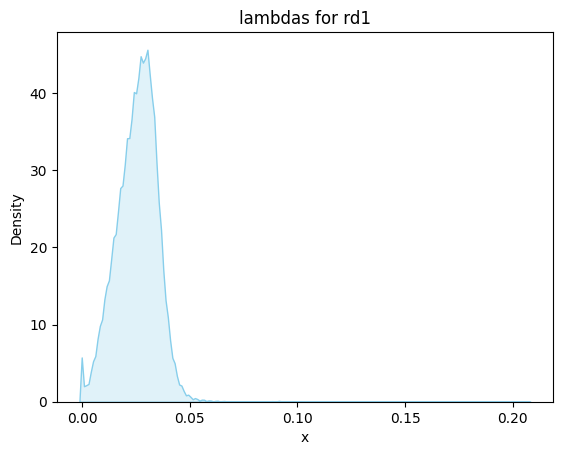

In [85]:
sns.kdeplot(lambdas, fill=True, color="skyblue")
plt.xlabel("x")
plt.ylabel("Density")
plt.title("lambdas for rd1")
plt.show()

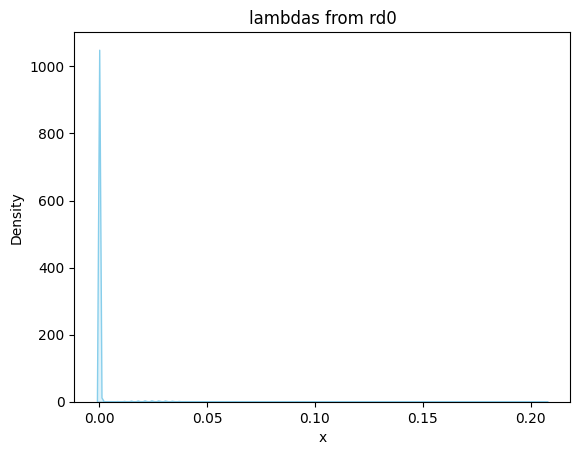

In [8]:
sns.kdeplot(lambda1['lambdas'], fill=True, color="skyblue")
plt.xlabel("x")
plt.ylabel("Density")
plt.title("lambdas from rd0")
plt.show()

In [13]:
lambda1['flag'].value_counts() 
# 7000 steps overfit
# 1000 steps on 10% uniref50 --> 8% trained
# 2000 steps on 10% uniref50 --> 16% trained

flag
0.0    5683580
1.0     512000
Name: count, dtype: int64

In [16]:
lambda1.describe()

,idx,flag,lambdas
count,6.195580e+06,6.195580e+06,6.195580e+06
mean,3.097790e+06,8.263956e-02,1.985742e-03
std,1.788510e+06,2.753367e-01,8.014186e-03
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.548895e+06,0.000000e+00,0.000000e+00
50%,3.097790e+06,0.000000e+00,0.000000e+00
75%,4.646684e+06,0.000000e+00,0.000000e+00
max,6.195579e+06,1.000000e+00,2.068750e-01


In [86]:
lambda1.loc[lambda1['lambdas'] == 0, :]                                                                                                                                                                                                                                                                                                                                                               


,idx,flag,lambdas
13382,13382,1.0,0.0
14962,14962,1.0,0.0
16086,16086,1.0,0.0
16406,16406,1.0,0.0
16513,16513,1.0,0.0
...,...,...,...
6195575,6195575,0.0,0.0
6195576,6195576,0.0,0.0
6195577,6195577,0.0,0.0
6195578,6195578,0.0,0.0


In [2]:
import pandas as pd
df = pd.read_csv('/hpc/group/naderilab/eleanor/AMPLIFY_ALLY/outputs/2025-10-22-00-43-42/lambdas_pred.csv')

In [3]:
df['pred_lambda'].isna().sum()

0

In [4]:
df.describe()

,pred_lambda
count,6.195580e+06
mean,2.136854e-02
std,1.353314e-02
min,0.000000e+00
25%,1.182864e-02
50%,2.140160e-02
75%,2.980759e-02
max,3.678997e-01


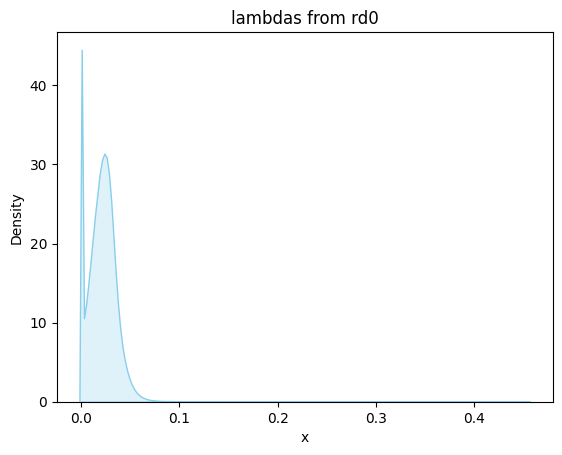

In [8]:
sns.kdeplot(df['pred_lambda'], fill=True, color="skyblue")
plt.xlabel("x")
plt.ylabel("Density")
plt.title("lambdas from rd0")
plt.show()

In [10]:
import pandas as pd
from tqdm import tqdm

lengths = []
idxs = []

with open('/hpc/group/naderilab/eleanor/AMPLIFY_ALLY/uniref/mila/uniref50_train.csv', 'r') as infile:
    header = next(infile)
    i = 0
    for line in tqdm(infile):
        fields = line.strip().split(',')
        seq = fields[-1]               # assuming sequence is last column
        lengths.append(len(seq))
        idxs.append(i)
        i += 1



61984724it [02:00, 516328.29it/s] 


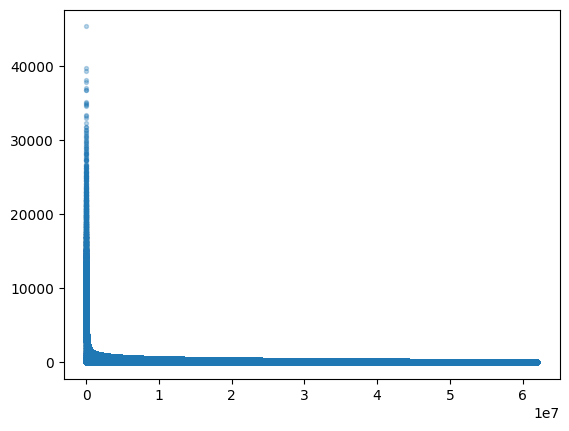

Text(0.5, 1.0, 'AMPLIFY Uniref 50 dataset')

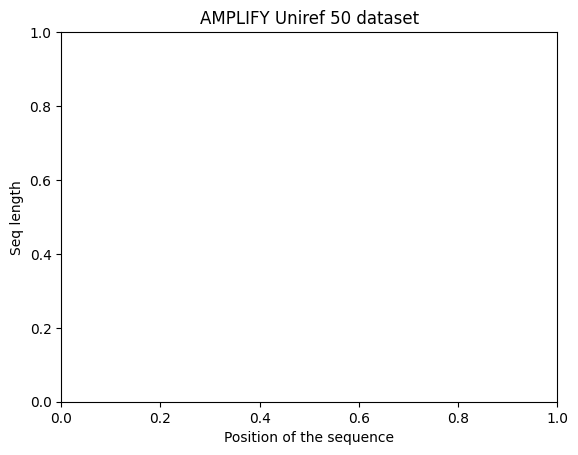

In [12]:
plt.scatter(idxs, lengths, s=8, alpha=0.3, c='tab:blue')
plt.show()
plt.xlabel('Position of the sequence')
plt.ylabel('Seq length')
plt.title('AMPLIFY Uniref 50 dataset')

## Lambdanet predictions

In [2]:
rd1_dir = "/hpc/group/naderilab/eleanor/AMPLIFY_ALLY/outputs/ALLY_nsamples.30M_niter.1_nsteps.20k_noslack_nclusters.2048_e.1.9_dualstep.5k_dualgamma.0.9_warmup.0/2026-01-07-08-51-26/"
rd2_dir = "/hpc/group/naderilab/eleanor/AMPLIFY_ALLY/outputs/ALLY_nsamples.30M_niter.1_nsteps.20k_noslack_nclusters.2048_e.1.9_dualstep.5k_dualgamma.0.9_warmup.0/2026-01-07-16-29-25/"
rd3_dir = "/hpc/group/naderilab/eleanor/AMPLIFY_ALLY/outputs/2025-12-25-01-42-13"
rd4_dir = "/hpc/group/naderilab/eleanor/AMPLIFY_ALLY/outputs/2025-12-25-06-57-20"

In [3]:
# emb1 = torch.from_numpy(np.load(os.path.join(rd1_dir, "embeddings.npy")))
lambda1 = pd.read_csv(os.path.join(rd1_dir, "lambdas.csv"))

# emb2 = torch.from_numpy(np.load(os.path.join(rd2_dir, "embeddings.npy")))
lambda2 = pd.read_csv(os.path.join(rd2_dir, "lambdas.csv"))


# emb3 = torch.from_numpy(np.load(os.path.join(rd3_dir, "embeddings.npy")))
# lambda1 = pd.read_csv(os.path.join(rd3_dir, "lambdas.csv"))

# emb4 = torch.from_numpy(np.load(os.path.join(rd4_dir, "embeddings.npy")))
# lambda1 = pd.read_csv(os.path.join(rd4_dir, "lambdas.csv"))

# print(f'rd1: shape of emb: {emb1.shape}, shape of lambdas: {lambda1.shape}')
# print(f'rd2 shape of emb: {emb2.shape}, shape of lambdas: {lambda2.shape}')
# print(f'rd3: shape of emb: {emb3.shape}, shape of lambdas: {lambda3.shape}')
# print(f'rd4 shape of emb: {emb4.shape}, shape of lambdas: {lambda4.shape}')

In [4]:
lambda1[(lambda1['flag'] == 0) & (lambda1['lambda_pred'] <= 0)]

,idx,flag,lambda_act,lambda_pred


In [9]:
# pct_trained = 2000*2*256//len(lambda1) = this number
len(lambda1[lambda1['flag'] != 0])/len(lambda1)

0.1652791183392031

In [6]:
lambda2[(lambda2['flag'] == 0) & (lambda2['lambda_pred'] <= 0)]

,idx,flag,lambda_act,lambda_pred


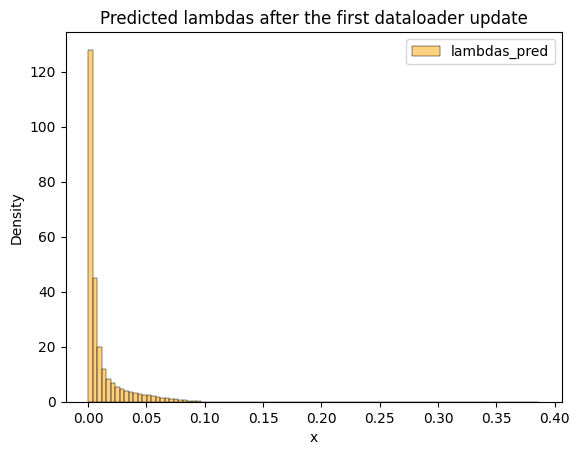

In [ ]:
actual_lambda = lambda1['lambda_act']
pred_lambda = lambda1['lambda_pred']

sns.histplot(
    pred_lambda,
    bins=100,         
    stat="density",    
    color="orange",
    alpha=0.5,
    label="lambdas_pred"
)

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Predicted lambdas after the first dataloader update")
plt.legend()
plt.show()

sns.histplot(
    actual_lambda,
    bins=100,         
    stat="density",  
    color="skyblue",
    alpha=0.5,
    label="lambdas_actual"
)

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Actual lambdas after the first rd")
plt.legend()
plt.show()

In [ ]:
actual_lambda = lambda2['lambda_act']
pred_lambda = lambda2['lambda_pred']

sns.histplot(
    pred_lambda,
    bins=100,         
    stat="density",    
    color="orange",
    alpha=0.5,
    label="lambdas_pred"
)

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Predicted lambdas after the second dataloader update")
plt.legend()
plt.show()

sns.histplot(
    actual_lambda,
    bins=100,         
    stat="density",  
    color="skyblue",
    alpha=0.5,
    label="lambdas_actual"
)

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Actual lambdas after the first rd")
plt.legend()
plt.show()

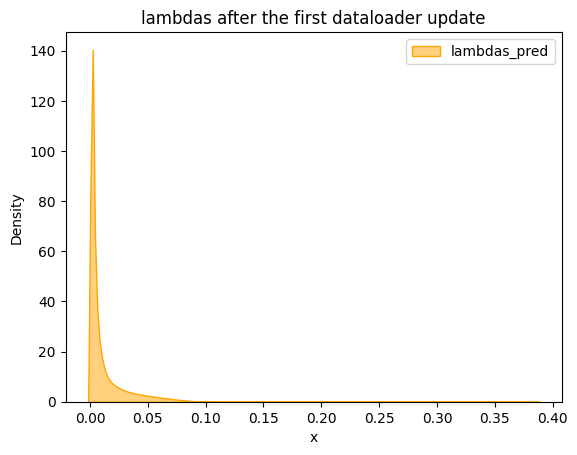

In [11]:
sns.kdeplot(
    pred_lambda,
    fill=True,
    color="orange",
    alpha=0.5,
    label="lambdas_pred"
)

plt.xlabel("x")
plt.ylabel("Density")
plt.title("lambdas after the first dataloader update")
plt.legend()
plt.show()


In [ ]:
actual_lambda = lambda2['lambda_act']
pred_lambda = lambda2['lambda_pred']

In [18]:
y_train = lambda1[lambda1['flag']>0]['lambdas']

y_min, y_max = y_train.min(), y_train.max()
y_min

0.0

In [19]:
len(lambda1[lambda1['flag'] == 0])/len(lambda1)

0.8347208816607969

In [28]:
print("untrained mean:", lambda1[lambda1['flag']== 0]['lambdas'].mean())


untrained mean: 0.0


In [30]:
print("frac(flag==0):", (lambda1['flag'] ==0).mean())
print("frac(lambda==0 | flag==0):", (lambda1[lambda1['flag'] ==0]==0).mean())
print("frac(lambda==0 | flag>0):", (lambda1[lambda1['flag']>0]==0).mean())


frac(flag==0): 0.8347208816607969
frac(lambda==0 | flag==0): idx            0.0
flag           1.0
lambdas        1.0
lambda_pred    0.0
dtype: float64
frac(lambda==0 | flag>0): idx            9.765625e-07
flag           0.000000e+00
lambdas        1.833887e-02
lambda_pred    1.833887e-02
dtype: float64
